In [11]:
from kagome_24_nn_2023_01_31 import (
    experiment_dir,
    fourier_learners_cache_dir,
    ground_state_cache_dir,
    nn_checkpoints_dir,
    nn_accuracy_file,
    system_accuracy_file,
    model_evaluation_file,
    lattice,
    signal_kind,
    FC1SpinNN,
)
import pandas as pd
import seaborn as sns
from heisenberg_hamiltonians import HeisenbergJ1J2
import torch
import torch.nn as nn
import torch.optim as optim
from lattice_boolean_analysis import (
    LBFFromNN,
    LBFFromSpinSystem,
    LatticeBooleanAnalyzer,
    LBATruncation,
    keep_largest_n,
)
import numpy as np
from spin_lattices import SpinLattice
import matplotlib.pyplot as plt
from parity import popcount
import seaborn as sns
import jsonlines


In [2]:
%matplotlib inline

In [12]:
def read_jsonl_to_df(file):
    with jsonlines.open(file) as reader:
        return pd.DataFrame(reader)

In [13]:
model_evaluation = read_jsonl_to_df(model_evaluation_file)

In [14]:
model_evaluation

,J2,eps_train,accuracy_test,sign_overlap_test,epoch,lattice,train_size
0,0.0,0.0001,0.502972,0.020417,1121,KagomeLattice2x4,17
1,0.0,0.0010,0.949182,0.900648,7689,KagomeLattice2x4,170
2,0.0,0.0500,0.991920,0.993463,1025,KagomeLattice2x4,8501
3,0.0,0.0100,0.994997,0.996245,1099,KagomeLattice2x4,1700
4,0.5,0.0001,0.502972,-0.009868,1360,KagomeLattice2x4,17
5,0.5,0.0010,0.824740,0.691992,10964,KagomeLattice2x4,170
6,0.5,0.0500,0.996221,0.998497,1023,KagomeLattice2x4,8501
7,0.5,0.0100,0.984617,0.984909,1228,KagomeLattice2x4,1700
8,0.6,0.0001,0.488980,-0.035515,1091,KagomeLattice2x4,17
9,0.6,0.0010,0.562097,0.174396,4204,KagomeLattice2x4,170


In [15]:
model_evaluation["nn_analyzer"] = None

for i, (J2, eps_train, accuracy_test, sign_overlap_test) in model_evaluation.iloc[
    :, :4
].iterrows():
    system = HeisenbergJ1J2(
        lattice=lattice,
        J1=1,
        J2=J2,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=ground_state_cache_dir,
        show_progress=True,
    )
    system.get_eigenstates(1)
    model_path = (
        nn_checkpoints_dir
        / f"FC1SpinNN-1hidden-64-sign-{system.system_id()}_eps_train={eps_train}.pt"
    )
    net = FC1SpinNN(lattice=system.lattice, hidden_size=64)
    net.load_state_dict(torch.load(model_path))

    nn_signal = LBFFromNN(
        lattice=lattice,
        nn=net,
        probs=system.get_df_ground_state(canonical_basis=True).assign(
            prob=lambda df: np.abs(df["eigenstate_coeff"]) ** 2
        )["prob"],
        network_id=str(model_path).replace("/", "_"),
    )

    nn_analyzer = LatticeBooleanAnalyzer(
        signal=nn_signal, show_progress=True, cache_dir=fourier_learners_cache_dir
    )
    try:
        nn_analyzer.fit(from_cache_only=True)
        model_evaluation.loc[i, "nn_analyzer"] = nn_analyzer
    except ValueError as e:
        print(f"Could not fit {model_path}")
        print(e)
        continue

    print(f"{J2!r},{eps_train},{accuracy_test},{sign_overlap_test}")

system_analyzers = {}
for J2 in model_evaluation["J2"].unique():
    system = HeisenbergJ1J2(
        lattice=lattice,
        J1=1,
        J2=J2,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=ground_state_cache_dir,
        show_progress=True,
    )
    system.get_eigenstates(1)
    system_signal = LBFFromSpinSystem(system=system, eigenstate=0, kind=signal_kind)
    system_analyzer = LatticeBooleanAnalyzer(
        signal=system_signal, show_progress=True, cache_dir=fourier_learners_cache_dir
    )
    try:
        system_analyzer.fit(from_cache_only=True)
        system_analyzers[J2] = system_analyzer
    except ValueError as e:
        print(f"Could not fit {J2}")
        print(e)
        continue
system_analyzers = pd.Series(system_analyzers).to_frame()


number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
Ground state energy is -46.1341392314


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


MFBSIS: Building Fourier basis...
MFBSIS: Computing state info...


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


MFBSIS: Computing sign flip basis correspondence...
MFBSIS: Computing fourier_basis_state_info_df...
Restoring learner from cache: fourier_learners_cache/88b79092f47aa89a858256165c32b492-experiments_kagome_24_nn_2023_01_31_nn_checkpoints_FC1SpinNN-1hidden-64-sign-HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1_eps_train=0.0001.pt-KagomeLattice2x4.lz
0.0,0.0001,0.5029717682020802,0.02041737176477909
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
Ground state energy is -46.1341392314
Restoring learner from cache: fourier_learners_cache/7c2bec6db3216a299f4067fcb5119d00-experiments_kagome_24_nn_2023_01_31_nn_checkpoints_FC1SpinNN-1hidden-64-sign-HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1_eps_train=0.001.pt-KagomeLattice2x4.lz
0.0,0.001,0.9491819533961329,0.9006479978561401
number_spins=24
Symmetry group contains 16 elements
Hil

In [16]:
nn_terms = read_jsonl_to_df(nn_accuracy_file).assign(
    terms=lambda x: pd.to_numeric(x["terms"], errors="coerce")
)


In [17]:
nn_terms


,lattice,terms,accuracy,sign_overlap,J2,eps_train
0,KagomeLattice2x4,1,0.980161,0.738940,0.0,0.0001
1,KagomeLattice2x4,1,0.939080,0.902779,0.0,0.0010
2,KagomeLattice2x4,1,0.979374,0.992456,0.0,0.0500
3,KagomeLattice2x4,1,0.992305,0.996312,0.0,0.0100
4,KagomeLattice2x4,1,0.835820,0.595522,0.5,0.0001
5,KagomeLattice2x4,1,0.789983,0.664493,0.5,0.0010
6,KagomeLattice2x4,1,0.986703,0.998083,0.5,0.0500
7,KagomeLattice2x4,1,0.964119,0.986542,0.5,0.0100
8,KagomeLattice2x4,1,0.999550,0.981249,0.6,0.0001
9,KagomeLattice2x4,1,0.769655,0.175620,0.6,0.0010


In [19]:
system_terms = read_jsonl_to_df(system_accuracy_file).assign(
    terms=lambda x: pd.to_numeric(x["terms"], errors="coerce")
)


In [20]:
system_terms


,lattice,terms,accuracy,sign_overlap,J2
0,KagomeLattice2x4,1,1.000000,1.000000,0.0
1,KagomeLattice2x4,1,0.946243,0.999968,0.5
2,KagomeLattice2x4,61,0.705711,0.935757,0.6


In [21]:
def total_hamming_weight(analyzer: LatticeBooleanAnalyzer, terms: int) -> int:
    return popcount(np.asarray(analyzer.learner.get_coeffs_ser().iloc[:terms].index)).sum()


In [23]:
def add_complexity_measures(df, analyzer_column="analyzer"):
    return (df.assign(
        hamming_weight=lambda df: df.apply(
            lambda row: total_hamming_weight(row[analyzer_column], int(row["terms"])), axis=1
        ),
        number_spins=lambda df: df[analyzer_column].apply(lambda a: a.number_spins),
    )
    .assign(
        mean_hw=lambda df: df["hamming_weight"] / df["terms"],
    ))

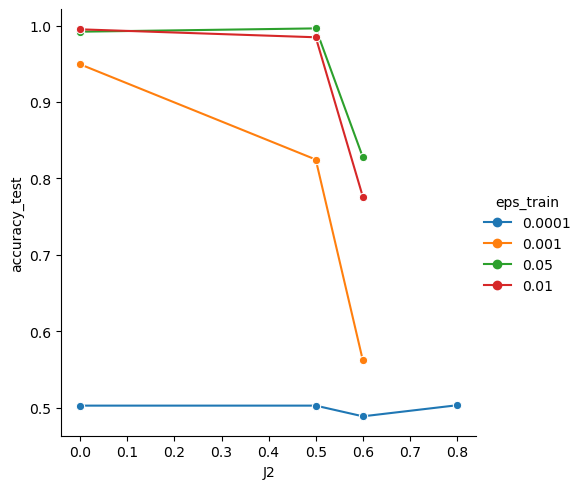

In [67]:
sns.relplot(model_evaluation.assign(eps_train=lambda df: df['eps_train'].astype(str)),
x="J2", y="accuracy_test", hue="eps_train", style="eps_train", kind="line", markers=['o'] * 4, dashes=False)

In [26]:
nn_terms

,lattice,terms,accuracy,sign_overlap,J2,eps_train
0,KagomeLattice2x4,1,0.980161,0.738940,0.0,0.0001
1,KagomeLattice2x4,1,0.939080,0.902779,0.0,0.0010
2,KagomeLattice2x4,1,0.979374,0.992456,0.0,0.0500
3,KagomeLattice2x4,1,0.992305,0.996312,0.0,0.0100
4,KagomeLattice2x4,1,0.835820,0.595522,0.5,0.0001
5,KagomeLattice2x4,1,0.789983,0.664493,0.5,0.0010
6,KagomeLattice2x4,1,0.986703,0.998083,0.5,0.0500
7,KagomeLattice2x4,1,0.964119,0.986542,0.5,0.0100
8,KagomeLattice2x4,1,0.999550,0.981249,0.6,0.0001
9,KagomeLattice2x4,1,0.769655,0.175620,0.6,0.0010


In [28]:
nn_complexity = add_complexity_measures(
    model_evaluation.dropna()
    .merge(nn_terms, on=["J2", "lattice", "eps_train"]),
    analyzer_column="nn_analyzer",
)


In [43]:
nn_complexity

,J2,eps_train,accuracy_test,sign_overlap_test,epoch,lattice,train_size,nn_analyzer,terms,accuracy,sign_overlap,hamming_weight,number_spins,mean_hw
0,0.0,0.0001,0.502972,0.020417,1121,KagomeLattice2x4,17,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.980161,0.738940,0,24,0.000000
1,0.0,0.0010,0.949182,0.900648,7689,KagomeLattice2x4,170,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.939080,0.902779,8,24,8.000000
2,0.0,0.0500,0.991920,0.993463,1025,KagomeLattice2x4,8501,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.979374,0.992456,8,24,8.000000
3,0.0,0.0100,0.994997,0.996245,1099,KagomeLattice2x4,1700,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.992305,0.996312,8,24,8.000000
4,0.5,0.0001,0.502972,-0.009868,1360,KagomeLattice2x4,17,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.835820,0.595522,0,24,0.000000
5,0.5,0.0010,0.824740,0.691992,10964,KagomeLattice2x4,170,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.789983,0.664493,8,24,8.000000
6,0.5,0.0500,0.996221,0.998497,1023,KagomeLattice2x4,8501,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.986703,0.998083,8,24,8.000000
7,0.5,0.0100,0.984617,0.984909,1228,KagomeLattice2x4,1700,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.964119,0.986542,8,24,8.000000
8,0.6,0.0001,0.488980,-0.035515,1091,KagomeLattice2x4,17,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.999550,0.981249,0,24,0.000000
9,0.6,0.0010,0.562097,0.174396,4204,KagomeLattice2x4,170,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.769655,0.175620,0,24,0.000000


In [29]:
nn_complexity

,J2,eps_train,accuracy_test,sign_overlap_test,epoch,lattice,train_size,nn_analyzer,terms,accuracy,sign_overlap,hamming_weight,number_spins,mean_hw
0,0.0,0.0001,0.502972,0.020417,1121,KagomeLattice2x4,17,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.980161,0.738940,0,24,0.000000
1,0.0,0.0010,0.949182,0.900648,7689,KagomeLattice2x4,170,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.939080,0.902779,8,24,8.000000
2,0.0,0.0500,0.991920,0.993463,1025,KagomeLattice2x4,8501,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.979374,0.992456,8,24,8.000000
3,0.0,0.0100,0.994997,0.996245,1099,KagomeLattice2x4,1700,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.992305,0.996312,8,24,8.000000
4,0.5,0.0001,0.502972,-0.009868,1360,KagomeLattice2x4,17,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.835820,0.595522,0,24,0.000000
5,0.5,0.0010,0.824740,0.691992,10964,KagomeLattice2x4,170,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.789983,0.664493,8,24,8.000000
6,0.5,0.0500,0.996221,0.998497,1023,KagomeLattice2x4,8501,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.986703,0.998083,8,24,8.000000
7,0.5,0.0100,0.984617,0.984909,1228,KagomeLattice2x4,1700,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.964119,0.986542,8,24,8.000000
8,0.6,0.0001,0.488980,-0.035515,1091,KagomeLattice2x4,17,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.999550,0.981249,0,24,0.000000
9,0.6,0.0010,0.562097,0.174396,4204,KagomeLattice2x4,170,<lattice_boolean_analysis.LatticeBooleanAnalyz...,1,0.769655,0.175620,0,24,0.000000


In [184]:
system_analyzers: pd.Series

In [31]:
system_complexity = add_complexity_measures(
    system_analyzers.reset_index()
    .rename(columns={"index": "J2", 0: "analyzer"})
    .merge(system_terms, on="J2")
)


In [36]:
compare_complexities = pd.concat(
    [
        nn_complexity.assign(signal="nn")
        .rename(columns={"nn_analyzer": "analyzer"})
        .query("eps_train == 0.001"),
        system_complexity.assign(signal="system"),
    ]
)


In [49]:
system_complexity.query("J2 == 0.6").fillna({"eps_train": 2})

,J2,analyzer,lattice,terms,accuracy,sign_overlap,hamming_weight,number_spins,mean_hw
2,0.6,<lattice_boolean_analysis.LatticeBooleanAnalyz...,KagomeLattice2x4,61,0.705711,0.935757,700,24,11.47541


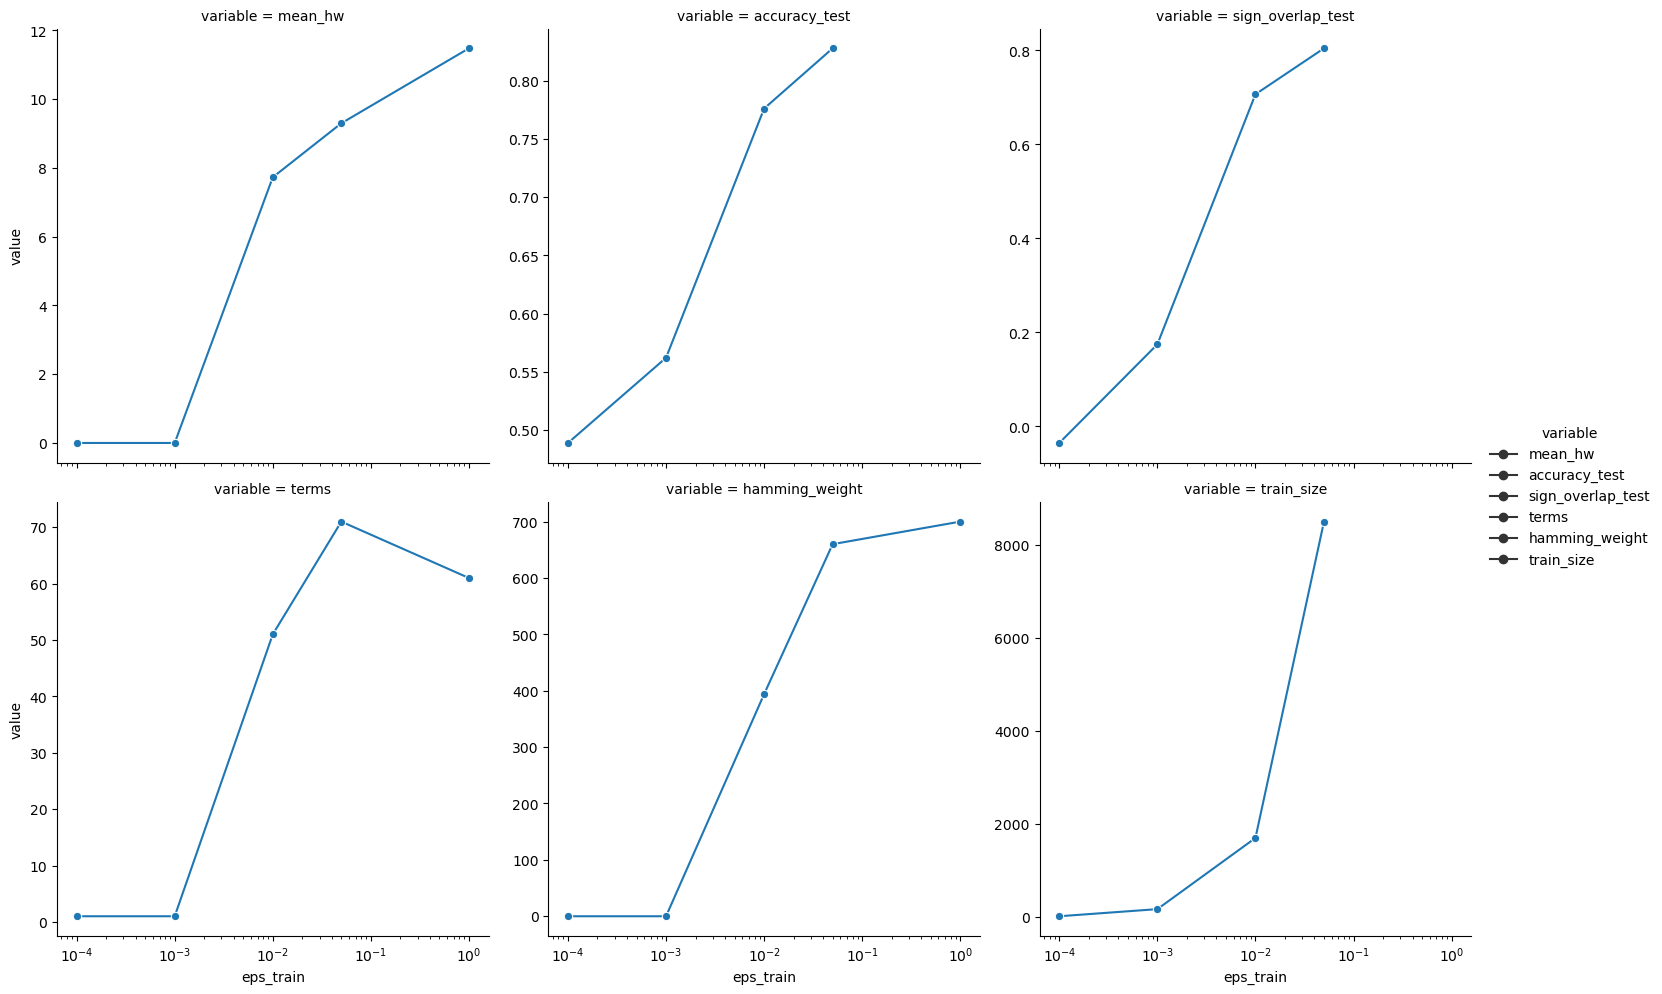

In [64]:
sns.relplot(data=pd.concat([nn_complexity.query("J2 == 0.6"), system_complexity.query("J2 == 0.6")])
    .fillna({"eps_train": 1})
    .melt(
        id_vars=["eps_train"],
        value_vars=[
            "mean_hw",
            "accuracy_test",
            "sign_overlap_test",
            "terms",
            "hamming_weight",
            "mean_hw",
            "train_size"
        ],
    ),
    x="eps_train",
    y="value",
    col="variable",
    col_wrap=3,
    # independent y axes
    facet_kws=dict(sharey=False),
    kind="line",
    markers=['o'] * 6,
    style='variable',
    dashes=False
).set(xscale="log")


In [38]:
def visualize_terms(truncation: LBATruncation):
    terms = truncation.truncate_strategy(truncation.analyzer.learner.get_coeffs_ser())
    fig, axes = plt.subplots(1, len(terms), figsize=(len(terms) * 3, 3), squeeze=False)
    for subset, term, ax in zip(terms.index, terms, axes[0]):
        truncation.analyzer.lattice.plot(spins=subset, ax=ax)
        # ax.set_title(f"{term:.2f}")
        # ax.axis('off')
        ax.set_xlabel(f"coeff = {term:.2f}")
        ax.set_ylabel("")
    plt.tight_layout()


In [39]:
nn_terms.assign(terms=lambda x: pd.to_numeric(x["terms"], errors="coerce"))

,lattice,terms,accuracy,sign_overlap,J2,eps_train
0,KagomeLattice2x4,1,0.980161,0.738940,0.0,0.0001
1,KagomeLattice2x4,1,0.939080,0.902779,0.0,0.0010
2,KagomeLattice2x4,1,0.979374,0.992456,0.0,0.0500
3,KagomeLattice2x4,1,0.992305,0.996312,0.0,0.0100
4,KagomeLattice2x4,1,0.835820,0.595522,0.5,0.0001
5,KagomeLattice2x4,1,0.789983,0.664493,0.5,0.0010
6,KagomeLattice2x4,1,0.986703,0.998083,0.5,0.0500
7,KagomeLattice2x4,1,0.964119,0.986542,0.5,0.0100
8,KagomeLattice2x4,1,0.999550,0.981249,0.6,0.0001
9,KagomeLattice2x4,1,0.769655,0.175620,0.6,0.0010


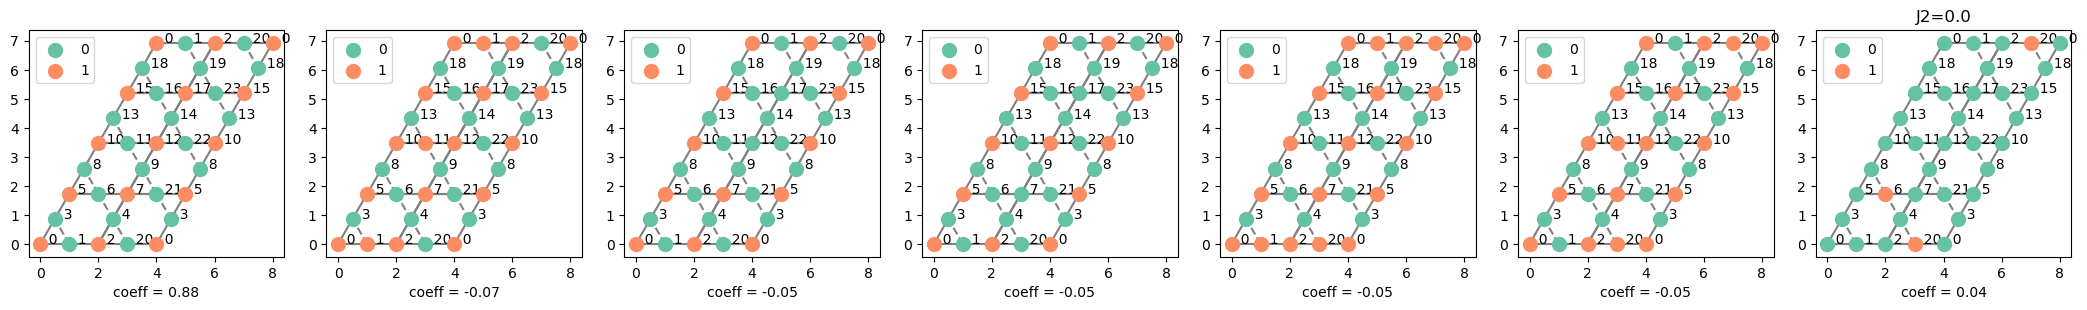

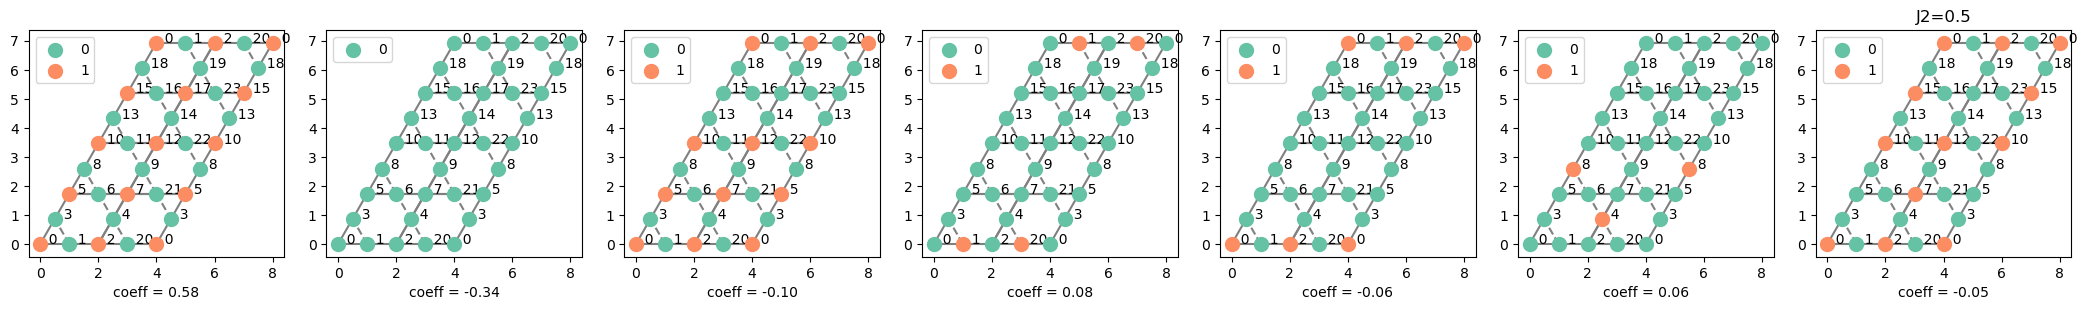

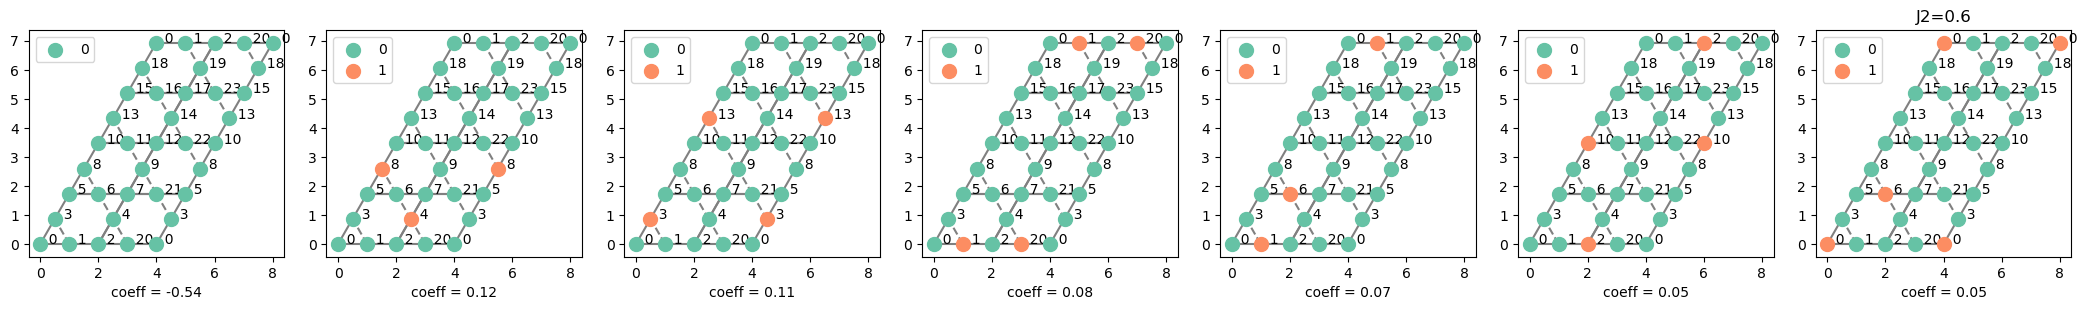

In [63]:
max_subsets = 7
eps_train = 0.001

for _, row in (
    model_evaluation.merge(nn_terms, on=["J2", "lattice", "eps_train"]).query("eps_train == @eps_train").iterrows()
):
    visualize_terms(
        row["nn_analyzer"].truncate(
            keep_largest_n(
                # int(min(max_subsets, row["terms"])) if not np.isnan(row["terms"]) else max_subsets
                max_subsets
            )
        )
    )
    plt.title(f"J2={row['J2']}")
    plt.show()
